In [19]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.makedirs('/content/gambar_mentah', exist_ok=True)

print("Mengekstrak gambar, tunggu sebentar...")
!unzip -q -j '/content/drive/MyDrive/RM/Dataset/HAM10000_Full.zip' -d /content/gambar_mentah/

total_gambar = len(os.listdir('/content/gambar_mentah'))
print(f"EKSTRAKSI SELESAI! Ada {total_gambar} gambar di dalam folder.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mengekstrak gambar, tunggu sebentar...
EKSTRAKSI SELESAI! Ada 20032 gambar di dalam folder.


In [20]:
from google.colab import files

uploaded = files.upload()

Saving HAM10000_metadata.csv to HAM10000_metadata.csv


In [21]:
import os
import pandas as pd
import shutil
from tqdm import tqdm

# Pastikan file CSV sudah ada di Colab
CSV_PATH = '/content/HAM10000_metadata.csv'
FOLDER_MENTAH = '/content/gambar_mentah'
FOLDER_TUJUAN = '/content/dataset_asli'

MEL_DIR = os.path.join(FOLDER_TUJUAN, 'melanoma')
NON_MEL_DIR = os.path.join(FOLDER_TUJUAN, 'non_melanoma')

os.makedirs(MEL_DIR, exist_ok=True)
os.makedirs(NON_MEL_DIR, exist_ok=True)
print("Folder tujuan berhasil dibuat.")

print("Membaca file CSV dan memulai sortir gambar...")

try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"ERROR: File '{CSV_PATH}' tidak ditemukan! Jangan lupa upload dulu file CSV-nya ya.")
    df = None

if df is not None:
    count_mel = 0
    count_non = 0

    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Menyortir Data"):
        nama_gambar = str(row['image_id']) + '.jpg'
        path_sumber = os.path.join(FOLDER_MENTAH, nama_gambar)

        kelas_penyakit = str(row['dx']).strip().lower()

        if os.path.exists(path_sumber):
            if kelas_penyakit == 'mel':
                path_tujuan = os.path.join(MEL_DIR, nama_gambar)
                count_mel += 1
            else:
                path_tujuan = os.path.join(NON_MEL_DIR, nama_gambar)
                count_non += 1

            shutil.move(path_sumber, path_tujuan)

    print("\nPROSES SORTIR SELESAI!")
    print(f"Jumlah Melanoma     : {count_mel} gambar")
    print(f"Jumlah Non-Melanoma : {count_non} gambar")

    if len(os.listdir(FOLDER_MENTAH)) == 0:
        os.rmdir(FOLDER_MENTAH)

Folder tujuan berhasil dibuat.
Membaca file CSV dan memulai sortir gambar...


Menyortir Data: 100%|██████████| 10015/10015 [00:01<00:00, 8305.55it/s]


PROSES SORTIR SELESAI!
Jumlah Melanoma     : 1113 gambar
Jumlah Non-Melanoma : 8902 gambar


# Pre-Processing

In [22]:
import cv2
import os
import glob
import numpy as np
from tqdm import tqdm

input_base_folder = '/content/dataset_asli'
output_base_folder = '/content/dataset_bersih_224'

daftar_kelas = ['melanoma', 'non_melanoma']

for kelas in daftar_kelas:
    input_folder = os.path.join(input_base_folder, kelas)
    output_folder = os.path.join(output_base_folder, kelas)

    os.makedirs(output_folder, exist_ok=True)

    image_paths = glob.glob(os.path.join(input_folder, '*.jpg'))

    if len(image_paths) == 0:
        print(f"\nTidak ada gambar di {input_folder}. Melewati kelas {kelas}...")
        continue

    print(f"\nMemulai proses untuk kelas: [{kelas.upper()}] - {len(image_paths)} gambar")

    for img_path in tqdm(image_paths, desc=f"Memproses {kelas}"):
        file_name = os.path.basename(img_path)

        img_bgr = cv2.imread(img_path)

        if img_bgr is None:
            print(f"\nFile corrupt dilewati: {file_name}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, mask = cv2.threshold(blackhat, 7, 255, cv2.THRESH_BINARY)

        inpainted = cv2.inpaint(img_rgb, mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)

        final_img = cv2.resize(inpainted, (224, 224))

        final_img_bgr = cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR)

        save_path = os.path.join(output_folder, file_name)
        cv2.imwrite(save_path, final_img_bgr)

print("\nEKSEKUSI SELESAI! Seluruh citra telah dibersihkan, di-resize, dan dipisahkan sesuai kelasnya di folder tujuan.")


Memulai proses untuk kelas: [MELANOMA] - 1113 gambar


Memproses melanoma: 100%|██████████| 1113/1113 [01:55<00:00,  9.63it/s]



Memulai proses untuk kelas: [NON_MELANOMA] - 8902 gambar


Memproses non_melanoma: 100%|██████████| 8902/8902 [12:56<00:00, 11.46it/s]


EKSEKUSI SELESAI! Seluruh citra telah dibersihkan, di-resize, dan dipisahkan sesuai kelasnya di folder tujuan.


# Data Splitting and Augmentation

In [23]:
import os
import cv2
import shutil
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm

if os.path.exists(PATH_OUTPUT):
    shutil.rmtree(PATH_OUTPUT)
    print("🧹 Folder lama dibersihkan.")

PATH_ASLI = '/content/dataset_bersih_224'
PATH_MEL = os.path.join(PATH_ASLI, 'melanoma')
PATH_NON_MEL = os.path.join(PATH_ASLI, 'non_melanoma')

PATH_OUTPUT = '/content/dataset_siap_ekstraksi'
for split in ['train', 'val', 'test']:
    for kelas in ['melanoma', 'non_melanoma']:
        os.makedirs(f'{PATH_OUTPUT}/{split}/{kelas}', exist_ok=True)

print("Memulai proses Data Splitting...")
mel_files     = sorted([f for f in os.listdir(PATH_MEL) if f.endswith(('.jpg','.png'))])
non_mel_files = sorted([f for f in os.listdir(PATH_NON_MEL) if f.endswith(('.jpg','.png'))])

mel_train_val, mel_test = train_test_split(mel_files, test_size=0.2, random_state=42)
mel_train, mel_val = train_test_split(mel_train_val, test_size=0.125, random_state=42)

non_train_val, non_test = train_test_split(non_mel_files, test_size=0.2, random_state=42)
non_train, non_val = train_test_split(non_train_val, test_size=0.125, random_state=42)

def copy_files(file_list, source_dir, dest_dir):
    for f in file_list:
        shutil.copy(os.path.join(source_dir, f), os.path.join(dest_dir, f))

copy_files(mel_train, PATH_MEL, f'{PATH_OUTPUT}/train/melanoma')
copy_files(mel_val, PATH_MEL, f'{PATH_OUTPUT}/val/melanoma')
copy_files(mel_test, PATH_MEL, f'{PATH_OUTPUT}/test/melanoma')

copy_files(non_train, PATH_NON_MEL, f'{PATH_OUTPUT}/train/non_melanoma')
copy_files(non_val, PATH_NON_MEL, f'{PATH_OUTPUT}/val/non_melanoma')
copy_files(non_test, PATH_NON_MEL, f'{PATH_OUTPUT}/test/non_melanoma')

print("\n--- DISTRIBUSI SEBELUM AUGMENTASI ---")
print(f"Data Latih (Train) -> Melanoma: {len(mel_train)} | Non-Melanoma: {len(non_train)}")

print("\nMemulai Augmentasi Gambar (Meningkatkan Spatial Invariance)...")
random.seed(42)

train_mel_dir = f'{PATH_OUTPUT}/train/melanoma'
jumlah_saat_ini = len(mel_train)

faktor_augmentasi = 1
total_augmentasi_baru = jumlah_saat_ini * faktor_augmentasi

def augment_image(image_path, save_dir, prefix):
    img = cv2.imread(image_path)
    if img is None: return

    teknik = random.choice(['flip_h', 'flip_v', 'rotate_90', 'rotate_180', 'zoom'])
    if teknik == 'flip_h': aug_img = cv2.flip(img, 1)
    elif teknik == 'flip_v': aug_img = cv2.flip(img, 0)
    elif teknik == 'rotate_90': aug_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif teknik == 'rotate_180': aug_img = cv2.rotate(img, cv2.ROTATE_180)
    elif teknik == 'zoom':
        h, w = img.shape[:2]
        crop_h, crop_w = int(h * 0.8), int(w * 0.8)
        y1, x1 = (h - crop_h) // 2, (w - crop_w) // 2
        cropped = img[y1:y1+crop_h, x1:x1+crop_w]
        aug_img = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    new_filename = f"aug_{prefix}_{teknik}_{os.path.basename(image_path)}"
    cv2.imwrite(os.path.join(save_dir, new_filename), aug_img)

for iterasi in tqdm(range(total_augmentasi_baru), desc="Proses Augmentasi 1x Salinan"):
    file_acak = mel_train[iterasi % jumlah_saat_ini]
    path_file_acak = os.path.join(train_mel_dir, file_acak)
    augment_image(path_file_acak, train_mel_dir, iterasi)

print("\n--- DISTRIBUSI SESUDAH AUGMENTASI ---")
print(f"Data Latih (Train) -> Melanoma: {len(os.listdir(train_mel_dir))} | Non-Melanoma: {len(non_train)}")
print("DATA SPLIT & AUGMENTASI SELESAI! Siap untuk Ekstraksi Fitur.")

Memulai proses Data Splitting...

--- DISTRIBUSI SEBELUM AUGMENTASI ---
Data Latih (Train) -> Melanoma: 778 | Non-Melanoma: 6230

Memulai Augmentasi Gambar (Meningkatkan Spatial Invariance)...


Proses Augmentasi 1x Salinan: 100%|██████████| 778/778 [00:00<00:00, 991.43it/s]


--- DISTRIBUSI SESUDAH AUGMENTASI ---
Data Latih (Train) -> Melanoma: 1556 | Non-Melanoma: 6230
DATA SPLIT & AUGMENTASI SELESAI! Siap untuk Ekstraksi Fitur.


# Ekstraksi 35 Fitur (Otsu + HSV + GLCM)

In [24]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import pandas as pd

BASE_PATH = '/content/dataset_siap_ekstraksi'
SPLITS = ['train', 'val', 'test']
CLASSES = ['melanoma', 'non_melanoma']

def extract_35_features_otsu(img_path):
    img = cv2.imread(img_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    if np.sum(mask == 255) < 1000:
        mask = np.ones(gray.shape, dtype=np.uint8) * 255

    features = []

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    for i in range(3):
        channel_pixels = hsv[:, :, i][mask == 255]

        if len(channel_pixels) == 0:
            features.extend([0]*5)
            continue

        mean = np.mean(channel_pixels)
        std = np.std(channel_pixels)

        sk = skew(channel_pixels)
        if np.isnan(sk): sk = 0

        kur = kurtosis(channel_pixels)
        if np.isnan(kur): kur = 0

        ran = np.max(channel_pixels) - np.min(channel_pixels)

        features.extend([mean, std, sk, kur, ran])

    gray_quantized = np.clip((gray // 16) + 1, 1, 16).astype(np.uint8)

    gray_quantized[mask == 0] = 0

    glcm_full = graycomatrix(
        gray_quantized,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=17, symmetric=True, normed=False
    )

    glcm_lesion = glcm_full[1:, 1:, :, :]

    glcm_sums = np.sum(glcm_lesion, axis=(0, 1), keepdims=True)
    glcm_sums[glcm_sums == 0] = 1
    glcm_normalized = glcm_lesion / glcm_sums

    features.extend(list(graycoprops(glcm_normalized, 'contrast')[0]))
    features.extend(list(graycoprops(glcm_normalized, 'energy')[0]))
    features.extend(list(graycoprops(glcm_normalized, 'correlation')[0]))
    features.extend(list(graycoprops(glcm_normalized, 'homogeneity')[0]))

    for a in range(4):
        glcm_prob = glcm_normalized[:, :, 0, a]
        ent = max(0.0, -np.sum(glcm_prob * np.log2(glcm_prob + 1e-10)))
        features.append(ent)

    return features

data_tabular = []
gambar_gagal = 0

for split in SPLITS:
    print(f"\nEkstraksi Set: {split.upper()}")
    for label in CLASSES:
        folder = os.path.join(BASE_PATH, split, label)

        valid_extensions = ('.jpg', '.jpeg', '.png')
        files = sorted([f for f in os.listdir(folder) if f.lower().endswith(valid_extensions)])

        print(f"   └── {label}: {len(files)} gambar")

        for f in tqdm(files):
            path = os.path.join(folder, f)
            feat = extract_35_features_otsu(path)

            if feat is not None and not any(np.isnan(val) or np.isinf(val) for val in feat):
                data_tabular.append(feat + [label, split])
            else:
                gambar_gagal += 1

kolom = [f'hsv_{i}' for i in range(15)] + [f'glcm_{i}' for i in range(20)] + ['label', 'split']
df = pd.DataFrame(data_tabular, columns=kolom)

folder_drive = '/content/drive/MyDrive/ML/GitHub/Dataset/'

os.makedirs(folder_drive, exist_ok=True)

csv_path = os.path.join(folder_drive, 'extracted_features_35_Tuned.csv')

df.to_csv(csv_path, index=False)

print(f"\nEKSTRAKSI SELESAI!")
print(f"File CSV berhasil diamankan di: {csv_path}")

total_diproses = len(data_tabular) + gambar_gagal
rasio_gagal = (gambar_gagal / total_diproses) * 100 if total_diproses > 0 else 0

print(f"\nLaporan Quality Control (QC):")
print(f"   Jumlah gambar sukses diekstrak : {len(data_tabular)}")
print(f"   Jumlah gambar dibuang          : {gambar_gagal} ({rasio_gagal:.2f}%)")

if rasio_gagal > 2.0:
    print("PERHATIAN: Rasio pembuangan data di atas 2%. Kemungkinan fitur GLCM Correlation menghasilkan NaN akibat augmentasi rotasi pada area yang terlalu homogen (Variance = 0).")


Ekstraksi Set: TRAIN
   └── melanoma: 1556 gambar


100%|██████████| 1556/1556 [00:14<00:00, 107.28it/s]


   └── non_melanoma: 6230 gambar


100%|██████████| 6230/6230 [00:55<00:00, 111.78it/s]



Ekstraksi Set: VAL
   └── melanoma: 112 gambar


...


Ekstraksi Set: TEST
   └── melanoma: 223 gambar


100%|██████████| 223/223 [00:02<00:00, 106.59it/s]


   └── non_melanoma: 1781 gambar


100%|██████████| 1781/1781 [00:15<00:00, 116.96it/s]



EKSTRAKSI SELESAI!
File CSV berhasil diamankan di: /content/drive/MyDrive/ML/GitHub/Dataset/extracted_features_35_Tuned.csv

Laporan Quality Control (QC):
   Jumlah gambar sukses diekstrak : 10793
   Jumlah gambar dibuang          : 0 (0.00%)


# Training and Evaluasi

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

print("1. Memuat Dataset 35 Fitur (Otsu + HSV + GLCM)...")

csv_path = '/content/drive/MyDrive/ML/Dataset/extracted_features_35_Tuned.csv'
df = pd.read_csv(csv_path)

df['label_encoded'] = np.where(df['label'] == 'melanoma', 1, 0)

train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

fitur_cols = [c for c in df.columns if c not in ['label', 'split', 'label_encoded']]

X_train, y_train = train_df[fitur_cols].values, train_df['label_encoded'].values
X_test, y_test = test_df[fitur_cols].values, test_df['label_encoded'].values

print(f"Distribusi Latih : Kanker={sum(y_train==1)} | Sehat={sum(y_train==0)}")
print(f"Distribusi Uji   : Kanker={sum(y_test==1)} | Sehat={sum(y_test==0)}")


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rasio_xgb = float(sum(y_train == 0)) / sum(y_train == 1)
print(f"\nRasio scale_pos_weight dinamis untuk XGBoost: {rasio_xgb:.2f}")

models = {
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        gamma=1,
        reg_lambda=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=rasio_xgb,
        random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=8,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    ),
    'SVM': SVC(
        C=10,
        gamma=0.01,
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    )
}

print("\n2. Melatih Ketiga Algoritma dengan Penalti (Class Weighting)...")
for name, model in models.items():
    print(f"Sedang melatih {name}...")
    model.fit(X_train_scaled, y_train)
print("Training selesai.")


print("\n================= DIAGNOSIS RAW TRAIN SET (DEFAULT THRESHOLD 0.50) =================")
print("Tujuan: Melihat seberapa baik model belajar sebelum di-tuning.\n")

for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)

    acc = accuracy_score(y_train, y_train_pred)
    rec = recall_score(y_train, y_train_pred)
    prec = precision_score(y_train, y_train_pred, zero_division=0)
    f1 = f1_score(y_train, y_train_pred, zero_division=0)

    cm = confusion_matrix(y_train, y_train_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"   HASIL TRAIN {name.upper()}")
    print(f"   Akurasi     : {acc*100:.2f}%")
    print(f"   Specificity : {spec*100:.2f}%")
    print(f"   F1-Score    : {f1*100:.2f}%")
    print(f"   Recall      : {rec*100:.2f}%")
    print(f"   Precision   : {prec*100:.2f}%")
    print("   " + "-"*40)

1. Memuat Dataset 35 Fitur (Otsu + HSV + GLCM)...
Distribusi Latih : Kanker=1556 | Sehat=6230
Distribusi Uji   : Kanker=223 | Sehat=1781

Rasio scale_pos_weight dinamis untuk XGBoost: 4.00

2. Melatih Ketiga Algoritma dengan Penalti (Class Weighting)...
Sedang melatih XGBoost...
Sedang melatih Extra Trees...
Sedang melatih SVM...
Training selesai.

================= DIAGNOSIS RAW TRAIN SET (DEFAULT THRESHOLD 0.50) =================
Tujuan: Melihat seberapa baik model belajar sebelum di-tuning.

   HASIL TRAIN XGBOOST
   Akurasi     : 91.16%
   Specificity : 89.17%
   F1-Score    : 81.77%
   Recall      : 99.16%
   Precision   : 69.57%
   ----------------------------------------
   HASIL TRAIN EXTRA TREES
   Akurasi     : 86.44%
   Specificity : 84.33%
   F1-Score    : 73.65%
   Recall      : 94.86%
   Precision   : 60.20%
   ----------------------------------------
   HASIL TRAIN SVM
   Akurasi     : 78.28%
   Specificity : 75.07%
   F1-Score    : 62.65%
   Recall      : 91.13%
   Prec

In [4]:
print("1. Menyiapkan Data Validation Set untuk Tuning...")

val_df = df[df['split'] == 'val']
X_val = val_df[fitur_cols].values
y_val = val_df['label_encoded'].values

X_val_scaled = scaler.transform(X_val)

print(f" Distribusi Validasi : Kanker={sum(y_val==1)} | Sehat={sum(y_val==0)}\n")

thresholds = np.arange(0.25, 0.55, 0.05)

path_simpan_gambar = '/content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

print("============ MEMULAI OPTIMASI THRESHOLD ============\n")

for name, model in models.items():
    print(f"==================================================")
    print(f" ANALISIS THRESHOLD: {name.upper()}")
    print(f"==================================================")

    prob_val = model.predict_proba(X_val_scaled)[:, 1]

    history_recall, history_precision, history_f1, history_acc, history_spec = [], [], [], [], []

    print(f"{'Threshold':<10} | {'Akurasi':<10} | {'Specificity':<12} | {'F1-Score':<10} | {'Recall':<10} | {'Precision':<10}")
    print("-" * 75)

    for thresh in thresholds:
        y_val_pred = np.where(prob_val >= thresh, 1, 0)

        acc = accuracy_score(y_val, y_val_pred)
        rec = recall_score(y_val, y_val_pred)
        prec = precision_score(y_val, y_val_pred, zero_division=0)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)

        cm = confusion_matrix(y_val, y_val_pred)
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        history_recall.append(rec)
        history_precision.append(prec)
        history_f1.append(f1)
        history_acc.append(acc)
        history_spec.append(spec)

        print(f"{thresh:<10.2f} | {acc*100:<9.2f}% | {spec*100:<11.2f}% | {f1*100:<9.2f}% | {rec*100:<9.2f}% | {prec*100:<9.2f}%")
    print("\n")


    plt.figure(figsize=(10, 6))

    plt.plot(thresholds, history_acc, label='Accuracy', color='#9B59B6', marker='D', linewidth=2.5)
    plt.plot(thresholds, history_spec, label='Specificity', color='#2ECC71', marker='*', linewidth=2.5)
    plt.plot(thresholds, history_f1, label='F1-Score (Balance)', color='#F1C40F', marker='^', linewidth=2.5)
    plt.plot(thresholds, history_recall, label='Recall (Sensitivity)', color='#E74C3C', marker='o', linewidth=2.5)
    plt.plot(thresholds, history_precision, label='Precision', color='#3498DB', marker='s', linewidth=2.5)

    plt.title(f'Threshold Optimization Curve - {name}\n(Validation Set)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Decision Threshold', fontsize=12, fontweight='bold')
    plt.ylabel('Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
    plt.xticks(thresholds)
    plt.ylim([0.0, 1.05])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)

    nama_file = f'Threshold_Tuning_{name.replace(" ", "_")}.png'
    path_gambar = os.path.join(path_simpan_gambar, nama_file)
    plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
    plt.close()

print(f"OPTIMASI SELESAI! Grafik Threshold Tuning (termasuk 5 metrik) berhasil disimpan di folder Drive.")

1. Menyiapkan Data Validation Set untuk Tuning...
 Distribusi Validasi : Kanker=112 | Sehat=891

============ MEMULAI OPTIMASI THRESHOLD ============

 ANALISIS THRESHOLD: XGBOOST
Threshold  | Akurasi    | Specificity  | F1-Score   | Recall     | Precision 
---------------------------------------------------------------------------
0.25       | 70.49    % | 68.35      % | 39.84    % | 87.50    % | 25.79    %
0.30       | 72.08    % | 71.27      % | 38.60    % | 78.57    % | 25.58    %
0.35       | 75.07    % | 75.08      % | 40.19    % | 75.00    % | 27.45    %
0.40       | 78.27    % | 79.12      % | 42.33    % | 71.43    % | 30.08    %
0.45       | 80.96    % | 82.72      % | 43.99    % | 66.96    % | 32.75    %
0.50       | 83.15    % | 85.75      % | 45.31    % | 62.50    % | 35.53    %
0.55       | 84.25    % | 88.33      % | 42.34    % | 51.79    % | 35.80    %


 ANALISIS THRESHOLD: EXTRA TREES
Threshold  | Akurasi    | Specificity  | F1-Score   | Recall     | Precision 
-------

In [5]:
print("================= TAHAP EVALUASI FINAL PADA TEST SET =================")
print("Menggunakan Optimal Operating Point Threshold\n")

optimal_thresholds = {
    'XGBoost': 0.50,
    'Extra Trees': 0.45,
    'SVM': 0.30
}

for name, model in models.items():
    current_thresh = optimal_thresholds[name]

    prob_test_final = model.predict_proba(X_test_scaled)[:, 1]

    y_test_pred = np.where(prob_test_final >= current_thresh, 1, 0)

    acc = accuracy_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_test = roc_auc_score(y_test, prob_test_final)

    print(f"   HASIL FINAL {name.upper()} (Threshold Kunci = {current_thresh})")
    print(f"   Akurasi     : {acc*100:.2f}%")
    print(f"   Specificity : {spec*100:.2f}%")
    print(f"   F1-Score    : {f1*100:.2f}%  <-- Titik Keseimbangan (Sweet Spot)")
    print(f"   Recall      : {rec*100:.2f}%  <-- Sensitivitas Medis")
    print(f"   Precision   : {prec*100:.2f}%")
    print(f"   AUC         : {auc_test:.4f}")
    print("   " + "-"*40)
    print(classification_report(y_test, y_test_pred, target_names=['Sehat (Non-Mel)', 'Kanker (Mel)']))
    print("\n")

print("Menyimpan Model dan Scaler ke Google Drive...")

path_simpan = '/content/drive/MyDrive/ML/GitHub/Dynamic_TH/'
os.makedirs(path_simpan, exist_ok=True)

joblib.dump(scaler, os.path.join(path_simpan, 'RobustScaler_35.pkl'))

for name, model in models.items():
    safe_name = name.replace(" ", "_")
    joblib.dump(model, os.path.join(path_simpan, f"{safe_name}_Model.pkl"))

print(f"SELURUH PROSES SELESAI! Model dengan Dynamic Threshold siap di-deploy. Tersimpan di: {path_simpan}")

================= TAHAP EVALUASI FINAL PADA TEST SET =================
Menggunakan Optimal Operating Point Threshold

   HASIL FINAL XGBOOST (Threshold Kunci = 0.5)
   Akurasi     : 80.39%
   Specificity : 82.20%
   F1-Score    : 42.79%  <-- Titik Keseimbangan (Sweet Spot)
   Recall      : 65.92%  <-- Sensitivitas Medis
   Precision   : 31.68%
   AUC         : 0.8372
   ----------------------------------------
                 precision    recall  f1-score   support

Sehat (Non-Mel)       0.95      0.82      0.88      1781
   Kanker (Mel)       0.32      0.66      0.43       223

       accuracy                           0.80      2004
      macro avg       0.63      0.74      0.65      2004
   weighted avg       0.88      0.80      0.83      2004



   HASIL FINAL EXTRA TREES (Threshold Kunci = 0.45)
   Akurasi     : 71.86%
   Specificity : 71.42%
   F1-Score    : 37.33%  <-- Titik Keseimbangan (Sweet Spot)
   Recall      : 75.34%  <-- Sensitivitas Medis
   Precision   : 24.82%
   AUC

# ROC/AUC

Creating ROC Curve plot and saving to Drive...


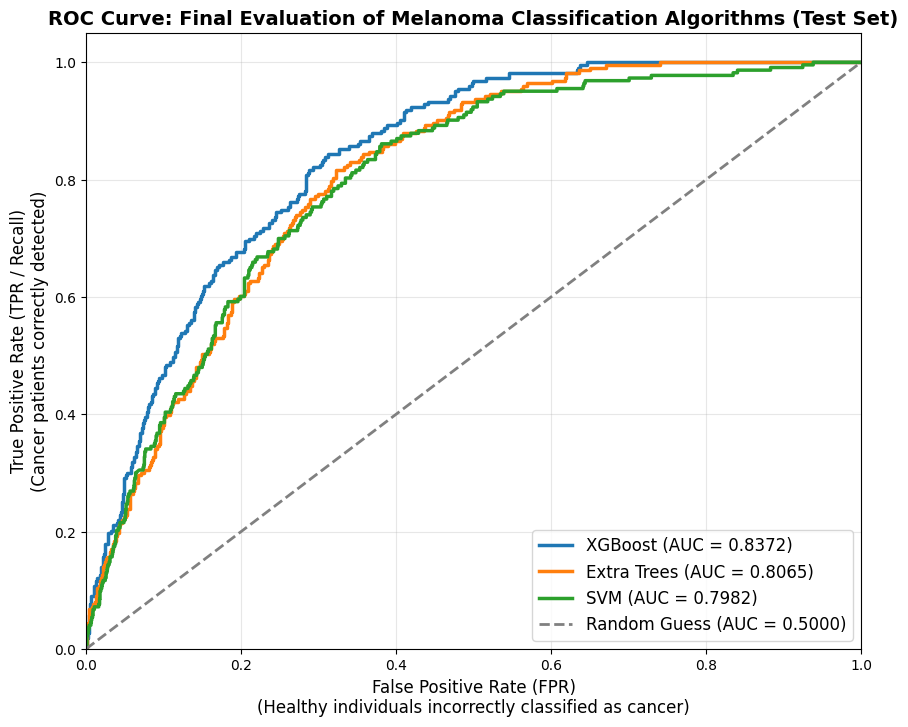

DONE! High-resolution ROC Curve saved at:
 /content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/ROC_Curve_Final_TestSet.png


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

print("Creating ROC Curve plot and saving to Drive...")

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

path_simpan_gambar = '/content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

for (name, model), color in zip(models.items(), colors):
    prob_test_roc = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob_test_roc)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)\n(Healthy individuals incorrectly classified as cancer)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)\n(Cancer patients correctly detected)', fontsize=12)
plt.title('ROC Curve: Final Evaluation of Melanoma Classification Algorithms (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

path_gambar = os.path.join(path_simpan_gambar, 'ROC_Curve_Final_TestSet.png')
plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
plt.show()

print(f"DONE! High-resolution ROC Curve saved at:\n {path_gambar}")

# Feature Importance

In [7]:
print("=========================================")
print("MAPPING FITUR WARNA (HSV) - 15 Fitur")
print("=========================================")
channels = ['Hue (H)', 'Saturation (S)', 'Value (V)']

metrics_hsv = ['Mean', 'Standard Deviation', 'Skewness', 'Kurtosis', 'Range']

idx = 0
for channel in channels:
    for metric in metrics_hsv:
        print(f"hsv_{idx} = {metric} of {channel} channel")
        idx += 1

print("\n=========================================")
print("MAPPING FITUR TEKSTUR (GLCM) - 20 Fitur")
print("=========================================")

metrics_glcm = ['Contrast', 'Energy', 'Correlation', 'Homogeneity', 'Entropy']
angles = ['0°', '45°', '90°', '135°']

idx = 0
for metric in metrics_glcm:
    for angle in angles:
        print(f"glcm_{idx} = {metric} at {angle} angle")
        idx += 1

MAPPING FITUR WARNA (HSV) - 15 Fitur
hsv_0 = Mean of Hue (H) channel
hsv_1 = Standard Deviation of Hue (H) channel
hsv_2 = Skewness of Hue (H) channel
hsv_3 = Kurtosis of Hue (H) channel
hsv_4 = Range of Hue (H) channel
hsv_5 = Mean of Saturation (S) channel
hsv_6 = Standard Deviation of Saturation (S) channel
hsv_7 = Skewness of Saturation (S) channel
hsv_8 = Kurtosis of Saturation (S) channel
hsv_9 = Range of Saturation (S) channel
hsv_10 = Mean of Value (V) channel
hsv_11 = Standard Deviation of Value (V) channel
hsv_12 = Skewness of Value (V) channel
hsv_13 = Kurtosis of Value (V) channel
hsv_14 = Range of Value (V) channel

MAPPING FITUR TEKSTUR (GLCM) - 20 Fitur
glcm_0 = Contrast at 0° angle
glcm_1 = Contrast at 45° angle
glcm_2 = Contrast at 90° angle
glcm_3 = Contrast at 135° angle
glcm_4 = Energy at 0° angle
glcm_5 = Energy at 45° angle
glcm_6 = Energy at 90° angle
glcm_7 = Energy at 135° angle
glcm_8 = Correlation at 0° angle
glcm_9 = Correlation at 45° angle
glcm_10 = Correl

Extracting Feature Importance from Ensemble Models...


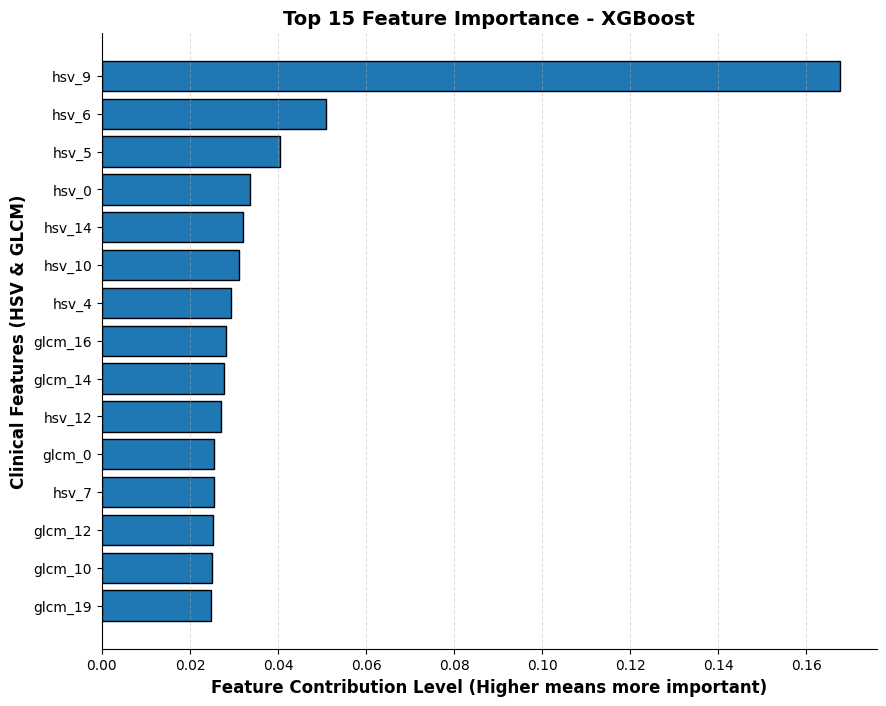

Feature Importance chart for XGBoost saved at:
 /content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/Feature_Importance_XGBoost.png



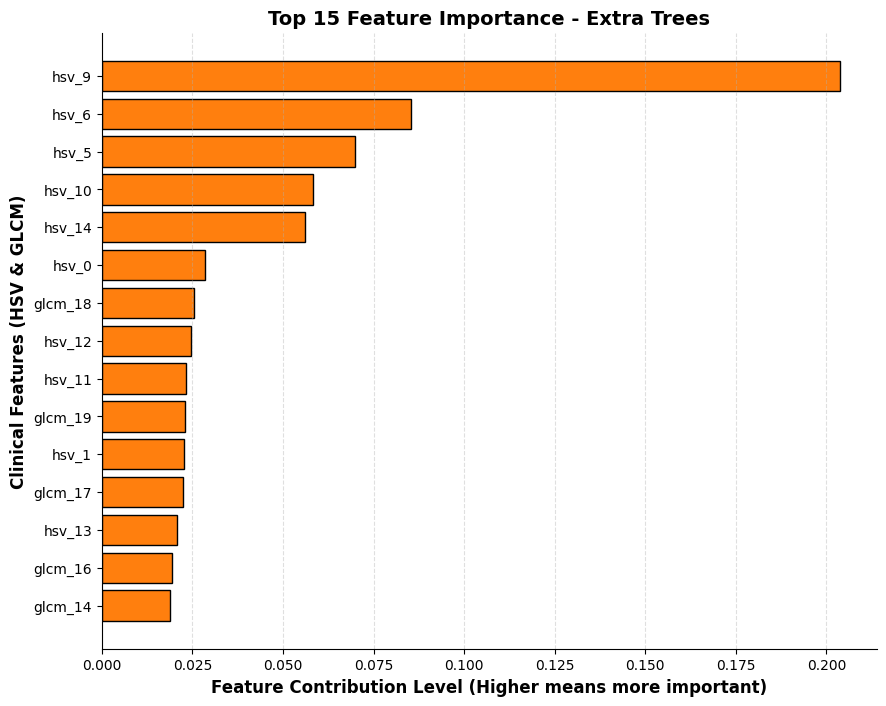

Feature Importance chart for Extra Trees saved at:
 /content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/Feature_Importance_Extra_Trees.png

Note: SVM (RBF Kernel) is skipped because it maps data into infinite dimensions, so it does not have built-in linear weight scores.


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import os

print("Extracting Feature Importance from Ensemble Models...")

path_simpan_gambar = '/content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

tree_models = ['XGBoost', 'Extra Trees']
warna_grafik = {'XGBoost': '#1f77b4', 'Extra Trees': '#ff7f0e'}

for name in tree_models:
    model = models[name]

    importances = model.feature_importances_

    df_imp = pd.DataFrame({
        'Feature': fitur_cols,
        'Importance Score': importances
    })

    df_top15 = df_imp.sort_values(by='Importance Score', ascending=True).tail(15)

    plt.figure(figsize=(10, 8))
    plt.barh(df_top15['Feature'], df_top15['Importance Score'], color=warna_grafik[name], edgecolor='black')

    plt.title(f'Top 15 Feature Importance - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Contribution Level (Higher means more important)', fontsize=12, fontweight='bold')
    plt.ylabel('Clinical Features (HSV & GLCM)', fontsize=12, fontweight='bold')
    plt.grid(axis='x', alpha=0.4, linestyle='--')

    plt.gca().spines[['top', 'right']].set_visible(False)

    path_gambar = os.path.join(path_simpan_gambar, f'Feature_Importance_{name.replace(" ", "_")}.png')
    plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Feature Importance chart for {name} saved at:\n {path_gambar}\n")

print("Note: SVM (RBF Kernel) is skipped because it maps data into infinite dimensions, so it does not have built-in linear weight scores.")

# Confusion Matrix and Specify

Calculating Confusion Matrix and Specificity (Dynamic Thresholds)...

 CONFUSION MATRIX REPORT: XGBOOST (Thresh: 0.5)
 True Negatives (TN) : 1464
 False Positives (FP): 317
 False Negatives (FN): 76
 True Positives (TP) : 147
-----------------------------------------
 SENSITIVITY (Recall) : 65.92%
 SPECIFICITY          : 82.20%



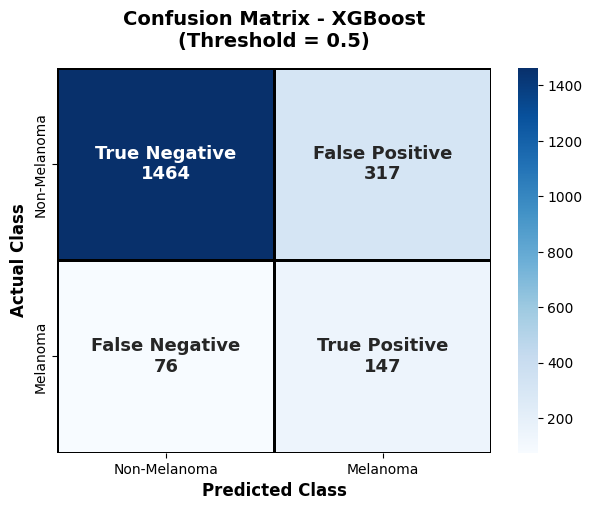


 CONFUSION MATRIX REPORT: EXTRA TREES (Thresh: 0.45)
 True Negatives (TN) : 1272
 False Positives (FP): 509
 False Negatives (FN): 55
 True Positives (TP) : 168
-----------------------------------------
 SENSITIVITY (Recall) : 75.34%
 SPECIFICITY          : 71.42%



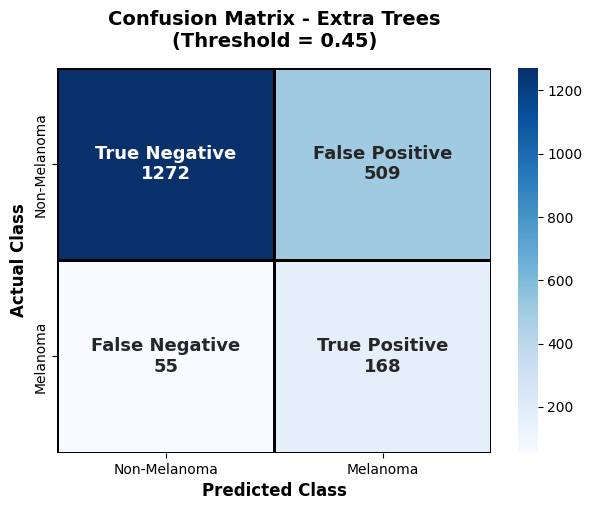


 CONFUSION MATRIX REPORT: SVM (Thresh: 0.3)
 True Negatives (TN) : 1474
 False Positives (FP): 307
 False Negatives (FN): 99
 True Positives (TP) : 124
-----------------------------------------
 SENSITIVITY (Recall) : 55.61%
 SPECIFICITY          : 82.76%



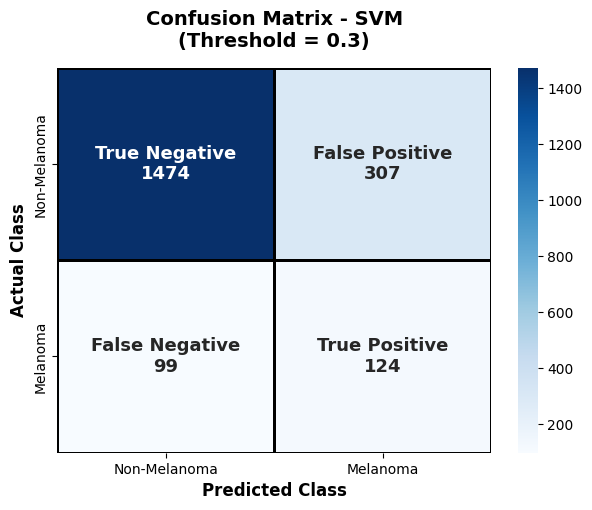

 Confusion Matrix visualizations (Dynamic Thresholds) saved in Google Drive!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

print("Calculating Confusion Matrix and Specificity (Dynamic Thresholds)...")

path_simpan_gambar = '/content/drive/MyDrive/ML/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

optimal_thresholds = {
    'XGBoost': 0.50,
    'Extra Trees': 0.45,
    'SVM': 0.30
}

for name, model in models.items():
    current_thresh = optimal_thresholds[name]

    prob_test = model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = np.where(prob_test >= current_thresh, 1, 0)

    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\n=========================================")
    print(f" CONFUSION MATRIX REPORT: {name.upper()} (Thresh: {current_thresh})")
    print(f"=========================================")
    print(f" True Negatives (TN) : {tn}")
    print(f" False Positives (FP): {fp}")
    print(f" False Negatives (FN): {fn}")
    print(f" True Positives (TP) : {tp}")
    print(f"-----------------------------------------")
    print(f" SENSITIVITY (Recall) : {recall*100:.2f}%")
    print(f" SPECIFICITY          : {specificity*100:.2f}%")
    print(f"=========================================\n")

    plt.figure(figsize=(7, 5))

    group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    group_counts = [f"{value}" for value in cm.flatten()]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Non-Melanoma', 'Melanoma'],
                yticklabels=['Non-Melanoma', 'Melanoma'],
                annot_kws={"size": 13, "weight": "bold"},
                linewidths=1, linecolor='black')

    plt.title(f'Confusion Matrix - {name}\n(Threshold = {current_thresh})', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

    path_gambar = os.path.join(path_simpan_gambar, f'Confusion_Matrix_{name.replace(" ", "_")}.png')
    plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
    plt.show()

print(" Confusion Matrix visualizations (Dynamic Thresholds) saved in Google Drive!")

# EDA

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pointbiserialr
import os
import warnings

warnings.filterwarnings('ignore')

print("Starting Advanced EDA process for PPT Presentation")

csv_path = '/content/drive/MyDrive/ML/GitHub/Dataset/extracted_features_35_Tuned.csv'
path_simpan_eda = '/content/drive/MyDrive/ML/GitHub/TH0.4/Hasil_Evaluasi/EDA/'
os.makedirs(path_simpan_eda, exist_ok=True)

df = pd.read_csv(csv_path)

print("Mengembalikan proporsi data ke kondisi asli dunia nyata (Reverse Augmentation)...")

jumlah_melanoma_sekarang = len(df[df['label'] == 'melanoma'])
jumlah_asli = 1113
kelebihan = jumlah_melanoma_sekarang - jumlah_asli

if kelebihan > 0:
    index_mel_train = df[(df['label'] == 'melanoma') & (df['split'] == 'train')].index

    np.random.seed(42)
    index_to_drop = np.random.choice(index_mel_train, size=kelebihan, replace=False)

    df = df.drop(index_to_drop).reset_index(drop=True)

print(f"Proporsi berhasil dikembalikan! Total Melanoma: {len(df[df['label'] == 'melanoma'])} | Non-Melanoma: {len(df[df['label'] == 'non_melanoma'])}")

kamus_fitur = {
    'hsv_0': 'Mean Hue', 'hsv_1': 'Std Hue', 'hsv_2': 'Variance Hue', 'hsv_3': 'Skewness Hue', 'hsv_4': 'Kurtosis Hue',
    'hsv_5': 'Mean Saturation', 'hsv_6': 'Std Saturation', 'hsv_7': 'Variance Saturation', 'hsv_8': 'Skewness Saturation', 'hsv_9': 'Kurtosis Saturation',
    'hsv_10': 'Mean Value', 'hsv_11': 'Std Value', 'hsv_12': 'Variance Value', 'hsv_13': 'Skewness Value', 'hsv_14': 'Kurtosis Value',

    'glcm_0': 'Contrast 0°', 'glcm_1': 'Contrast 45°', 'glcm_2': 'Contrast 90°', 'glcm_3': 'Contrast 135°',
    'glcm_4': 'Energy 0°', 'glcm_5': 'Energy 45°', 'glcm_6': 'Energy 90°', 'glcm_7': 'Energy 135°',
    'glcm_8': 'Correlation 0°', 'glcm_9': 'Correlation 45°', 'glcm_10': 'Correlation 90°', 'glcm_11': 'Correlation 135°',
    'glcm_12': 'Homogeneity 0°', 'glcm_13': 'Homogeneity 45°', 'glcm_14': 'Homogeneity 90°', 'glcm_15': 'Homogeneity 135°',
    'glcm_16': 'Entropy 0°', 'glcm_17': 'Entropy 45°', 'glcm_18': 'Entropy 90°', 'glcm_19': 'Entropy 135°'
}

df = df.rename(columns=kamus_fitur)

missing = [v for v in kamus_fitur.values() if v not in df.columns]
if missing:
    print(f"WARNING: {len(missing)} features not found. Example: {missing[:5]}")
else:
    print("All 35 features successfully verified and translated!")

df['binary_label'] = df['label'].apply(lambda x: 1 if x == 'melanoma' else 0)
df['Diagnosis'] = df['label'].apply(lambda x: 'Melanoma' if x == 'melanoma' else 'Non-Melanoma')

feature_cols = [v for v in kamus_fitur.values() if v in df.columns]

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')
palette = {'Melanoma': '#E74C3C', 'Non-Melanoma': '#2ECC71'}

print("Processing and generating 5 main charts in English...")

class_counts = df['Diagnosis'].value_counts()
total = len(df)
colors_dist = ['#2ECC71', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('HAM10000 Dataset Class Distribution\n(Raw Medical Data Representation)', fontsize=14, fontweight='bold', y=1.05)

bars = axes[0].bar(class_counts.index, class_counts.values, color=colors_dist, width=0.5, edgecolor='black', linewidth=1)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Number of Images per Class', fontsize=12)
axes[0].set_ylim(0, class_counts.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
    colors=colors_dist, startangle=90, explode=(0, 0.08), wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Data Imbalance Proportion', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(path_simpan_eda, '1_Class_Distribution_Raw.png'), bbox_inches='tight')
plt.close()

pb_corr = {}
for col in feature_cols:
    r, _ = pointbiserialr(df['binary_label'], df[col].fillna(0))
    pb_corr[col] = r

pb_series = pd.Series(pb_corr).sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E74C3C' if v > 0 else '#3498DB' for v in pb_series.values]
bars = ax.barh(pb_series.index[::-1], pb_series.values[::-1], color=bar_colors[::-1], edgecolor='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

min_val = pb_series.min()
max_val = pb_series.max()
ax.set_xlim(min_val - 0.08, max_val + 0.08)

for bar, val in zip(bars, pb_series.values[::-1]):
    ax.text(val + (0.015 if val >= 0 else -0.015), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9, fontweight='bold')

ax.set_xlabel('Correlation Value towards Melanoma Diagnosis', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Clinical Extracted Features (Point-Biserial Correlation)', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(path_simpan_eda, '2_Top15_Feature_Correlation_Raw.png'), bbox_inches='tight')
plt.close()

top_6_features = pb_series.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Comparison Boxplots: Melanoma vs Non-Melanoma', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(top_6_features):
    data_mel = df[df['Diagnosis'] == 'Melanoma'][col]
    data_nonmel = df[df['Diagnosis'] == 'Non-Melanoma'][col]

    bp = axes[i].boxplot([data_mel, data_nonmel], patch_artist=True, labels=['Melanoma', 'Non-Melanoma'], widths=0.4, showfliers=False)

    bp['boxes'][0].set_facecolor('#E74C3C')
    bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor('#2ECC71')
    bp['boxes'][1].set_alpha(0.8)

    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].tick_params(labelsize=10)
    axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(path_simpan_eda, '3_Boxplot_Top6_Raw.png'), bbox_inches='tight')
plt.close()

top_4_features = pb_series.index[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dominant Feature Density Distribution\n(Why the Machine Selected These Features)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(top_4_features):
    sns.histplot(data=df, x=col, hue='Diagnosis', palette=palette,
                 kde=True, stat='density', common_norm=False,
                 ax=axes[i], alpha=0.5, line_kws={'linewidth': 2.5})

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(path_simpan_eda, '4_Histogram_Overlay_Top4_Raw.png'), bbox_inches='tight')
plt.close()

top_15_cols = pb_series.index.tolist()
mini_corr_matrix = df[top_15_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(mini_corr_matrix, dtype=bool))
sns.heatmap(
    mini_corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Mini Heatmap: Top 15 Dominant Features', fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(path_simpan_eda, '5_Mini_Heatmap_Top15_Raw.png'), bbox_inches='tight')
plt.close()

print(f"EDA COMPLETED!\n 5 fully English charts (Raw Data) have been safely stored in: {path_simpan_eda}")

Starting Advanced EDA process for PPT Presentation
Mengembalikan proporsi data ke kondisi asli dunia nyata (Reverse Augmentation)...
Proporsi berhasil dikembalikan! Total Melanoma: 1113 | Non-Melanoma: 8902
All 35 features successfully verified and translated!
Processing and generating 5 main charts in English...
EDA COMPLETED!
 5 fully English charts (Raw Data) have been safely stored in: /content/drive/MyDrive/ML/GitHub/TH0.4/Hasil_Evaluasi/EDA/


# Visualisasi EDA Tambahan

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

print("Generating Basic EDA Visualizations (Data Quality Check)...")

csv_path = '/content/drive/MyDrive/ML/GitHub/Dataset/extracted_features_35_Tuned.csv'
path_simpan = '/content/drive/MyDrive/ML/GitHub/TH0.4/Hasil_Evaluasi/EDA/'
os.makedirs(path_simpan, exist_ok=True)

df = pd.read_csv(csv_path)

sample_features = ['hsv_5', 'hsv_9', 'glcm_10', 'glcm_17']
feature_names = ['Mean Saturation', 'Kurtosis Saturation', 'Correlation 90°', 'Entropy 45°']
df_sample = df[sample_features].copy()
df_sample.columns = feature_names

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

non_null_counts = df.notnull().sum().head(15)
total_rows = len(df)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(non_null_counts.index[::-1], non_null_counts.values[::-1], color='#3498DB', edgecolor='black')

ax.axvline(total_rows, color='#E74C3C', linestyle='--', linewidth=2, label=f'Max Rows ({total_rows})')

for bar in bars:
    ax.text(bar.get_width() - 500, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', ha='right', color='white', fontweight='bold')

ax.set_title('Data Completeness Check (Missing Values Verification)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Non-Null Entries', fontsize=11, fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(path_simpan, 'Basic_1_Missing_Values_Barplot.png'), bbox_inches='tight')
plt.close()


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_sample, orient='h', palette='Set2',
            showfliers=True,
            flierprops=dict(markerfacecolor='#E74C3C', marker='o', markersize=5, alpha=0.6))

ax.set_title('Feature Distribution & Outlier Detection (Clinical Anomalies)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Feature Values', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)


plt.figtext(0.15, -0.05, "Note: Red dots indicate outliers (extreme values). In this medical context,\nthese anomalies are retained as they represent critical visual characteristics of Melanoma.",
            fontsize=9, style='italic', bbox=dict(facecolor='yellow', alpha=0.2))

plt.tight_layout()
plt.savefig(os.path.join(path_simpan, 'Basic_2_Outliers_Boxplot.png'), bbox_inches='tight')
plt.close()

print(f"EDA VISUALIZATIONS COMPLETED!\n 2 Charts for your thesis book are saved in: {path_simpan}")

Generating Basic EDA Visualizations (Data Quality Check)...
EDA VISUALIZATIONS COMPLETED!
 2 Charts for your thesis book are saved in: /content/drive/MyDrive/ML/GitHub/TH0.4/Hasil_Evaluasi/EDA/


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')


print("Importing dataset and preparing storage folder...")
csv_path = '/content/drive/MyDrive/ML/GitHub/Dataset/extracted_features_35_Tuned.csv'

path_simpan_basic = '/content/drive/MyDrive/ML/GitHub/TH0.4/Hasil_Evaluasi/Basic_EDA/'
os.makedirs(path_simpan_basic, exist_ok=True)

data = pd.read_csv(csv_path)

print("\n[INFO] Dataset Dimensions:")
print(data.shape)

print("\n[INFO] Checking for Missing Values (NaN):")
missing = data.isnull().sum().sort_values(ascending=False)
missing_df = missing[missing > 0]

if missing_df.empty:
    print("Perfect! No missing values found in this dataset.")
else:
    print("Missing values detected!")

print("\nSaving Chart 1: Class Distribution...")

data['Diagnosis'] = data['label'].apply(lambda x: 'Melanoma' if x == 'melanoma' else 'Non-Melanoma')

plt.figure(figsize=(7, 5))
sns.countplot(data=data, x='Diagnosis', palette={'Melanoma': '#E74C3C', 'Non-Melanoma': '#2ECC71'},
              edgecolor='black', order=['Non-Melanoma', 'Melanoma'])
plt.title('Skin Disease Class Distribution\n(Imbalance Data Check)')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Images (Frequency)')

counts = data['Diagnosis'].value_counts()
for i, label_name in enumerate(['Non-Melanoma', 'Melanoma']):
    count = counts.get(label_name, 0)
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontweight='bold')

plt.savefig(os.path.join(path_simpan_basic, '1_Class_Distribution.png'), bbox_inches='tight')
plt.close()

print("Saving Chart 2: Outlier Boxplot...")
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["hsv_5"], color='skyblue')
plt.title('Box Plot for Mean Saturation (hsv_5)')
plt.xlabel('Mean Saturation Value')

plt.savefig(os.path.join(path_simpan_basic, '2_Outlier_Boxplot.png'), bbox_inches='tight')
plt.close()

print("Saving Chart 3: Correlation Heatmap...")
data['binary_label'] = data['label'].apply(lambda x: 1 if x == 'melanoma' else 0)

numeric_data = data.select_dtypes(include=[np.number])

top_correlations = numeric_data.corr()['binary_label'].abs().sort_values(ascending=False)[1:6]
top_5_cols = top_correlations.index.tolist()

plt.figure(figsize=(8, 6))
cols_for_heatmap = top_5_cols + ['binary_label']
korelasi_top5 = numeric_data[cols_for_heatmap].corr()

sns.heatmap(korelasi_top5, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Top 5 Most Influential Features on Melanoma')

plt.savefig(os.path.join(path_simpan_basic, '3_Correlation_Heatmap.png'), bbox_inches='tight')
plt.close()

print(f"\nBASIC EDA COMPLETED! All charts have been safely stored in:\n {path_simpan_basic}")

Importing dataset and preparing storage folder...

[INFO] Dataset Dimensions:
(10793, 37)

[INFO] Checking for Missing Values (NaN):
Perfect! No missing values found in this dataset.

Saving Chart 1: Class Distribution...
Saving Chart 2: Outlier Boxplot...
Saving Chart 3: Correlation Heatmap...

BASIC EDA COMPLETED! All charts have been safely stored in:
 /content/drive/MyDrive/ML/GitHub/TH0.4/Hasil_Evaluasi/Basic_EDA/
